In [161]:
import numpy as np
from pathlib import Path 
import pandas as pd 
import ast
import seaborn as sns

from sklearn.svm import SVC
from sklearn.utils import resample

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier 
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, cross_validate
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix, auc
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import xgboost as xgb

import matplotlib
import matplotlib.pyplot as plt
np.random.seed(42)

In [162]:
EMBED_DIR = Path(r'D:\Users\UFPB\gabriel ayres\MST\results-classification-preprocessed2\runs\PENN\ResNetSliceTrans_2025_06_06_192329_multi\embeddings-correct')
split_file = Path(r'D:\Users\UFPB\gabriel ayres\MST\notebooks\penn-preprocessed_datasplit.csv')
to_exclude_path = Path(r"D:\Users\UFPB\gabriel ayres\MST\scripts\preprocessing\penn-preprocessed\to_exclude.txt") 

df_splits = pd.read_csv(split_file)
embeds = [np.load(embed)['pred'] for embed in EMBED_DIR.glob('*.npz')]
print(embeds[0].shape)

embeds_flat = embeds.reshape(embeds.shape[0], -1)
print(f"Flattened embeddings shape: {embeds_flat.shape}")



(1, 384)


AttributeError: 'list' object has no attribute 'reshape'

x_train shape before flattening: (312, 1, 384)
x_test shape before flattening: (78, 1, 384)
x_train_flat shape: (312, 384)
x_test_flat shape: (78, 384)
Running analysis with fixed function...
Using data shapes:
x_train_resampled: (576, 384)
y_train_resampled: (576,)
x_test_flat: (78, 384)
y_test: (78,)

--- Analyzing Model: Logistic Regression ---
Prediction probabilities - min: 0.0000, max: 0.8937
Test labels unique: [0 1]
Std Dev of AUCs: 0.0966


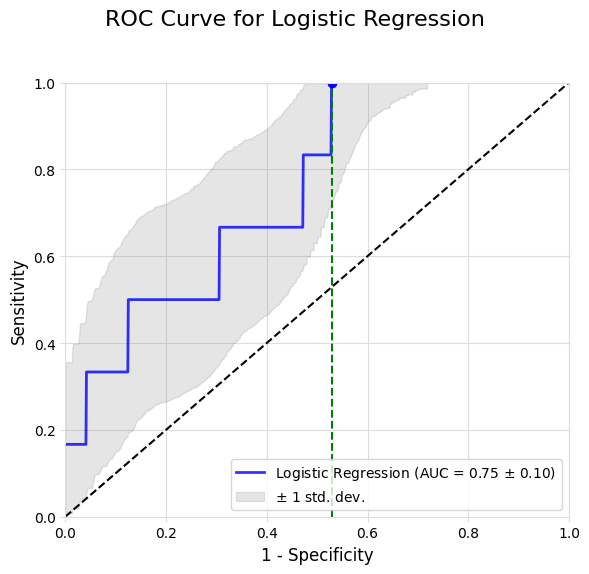

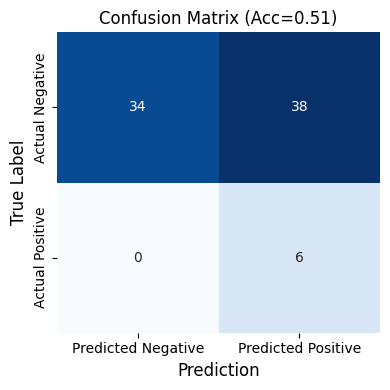

Results for Logistic Regression at Optimal Threshold:
AUC: 0.75
Accuracy: 0.51
Sensitivity (Recall): 1.00
Specificity: 0.47
Error with model Logistic Regression: index 528 is out of bounds for axis 0 with size 79
--------------------------------------------

--- Analyzing Model: Random Forest ---


Traceback (most recent call last):
  File "C:\Users\nascime9\AppData\Local\Temp\ipykernel_16840\3191338975.py", line 207, in analyze_and_plot_models_fixed
    print(f"Optimal Threshold: {thrs[opt_idx]:.4f}")
                                ~~~~^^^^^^^^^
IndexError: index 528 is out of bounds for axis 0 with size 79


Prediction probabilities - min: 0.0000, max: 0.7200
Test labels unique: [0 1]
Std Dev of AUCs: 0.1242


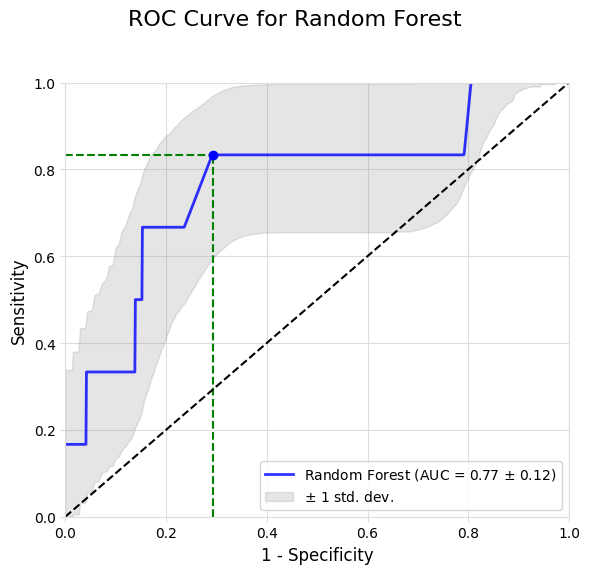

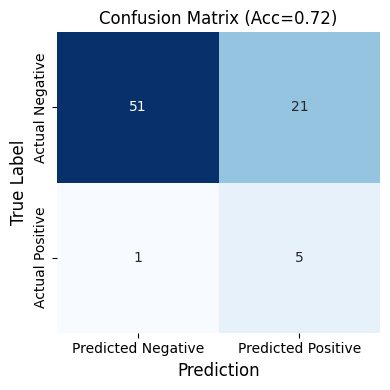

Results for Random Forest at Optimal Threshold:
AUC: 0.77
Accuracy: 0.72
Sensitivity (Recall): 0.83
Specificity: 0.71
Error with model Random Forest: index 292 is out of bounds for axis 0 with size 38
--------------------------------------

--- Analyzing Model: SVC ---
Prediction probabilities - min: 0.0031, max: 0.9183
Test labels unique: [0 1]


Traceback (most recent call last):
  File "C:\Users\nascime9\AppData\Local\Temp\ipykernel_16840\3191338975.py", line 207, in analyze_and_plot_models_fixed
    print(f"Optimal Threshold: {thrs[opt_idx]:.4f}")
                                ~~~~^^^^^^^^^
IndexError: index 292 is out of bounds for axis 0 with size 38


Std Dev of AUCs: 0.1227


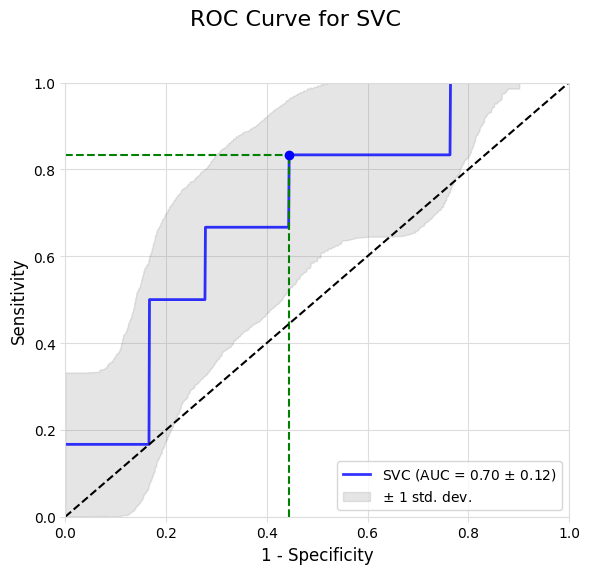

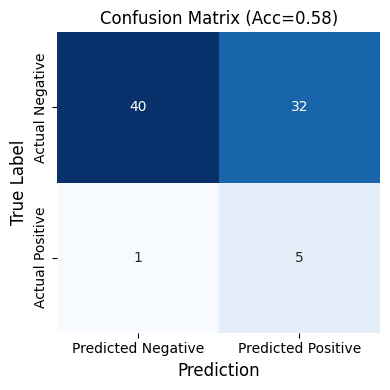

Results for SVC at Optimal Threshold:
AUC: 0.70
Accuracy: 0.58
Sensitivity (Recall): 0.83
Specificity: 0.56
Error with model SVC: index 444 is out of bounds for axis 0 with size 79
----------------------------

--- Analyzing Model: Hist Gradient Boosting ---


Traceback (most recent call last):
  File "C:\Users\nascime9\AppData\Local\Temp\ipykernel_16840\3191338975.py", line 207, in analyze_and_plot_models_fixed
    print(f"Optimal Threshold: {thrs[opt_idx]:.4f}")
                                ~~~~^^^^^^^^^
IndexError: index 444 is out of bounds for axis 0 with size 79


Prediction probabilities - min: 0.0000, max: 0.9538
Test labels unique: [0 1]
Std Dev of AUCs: 0.1333


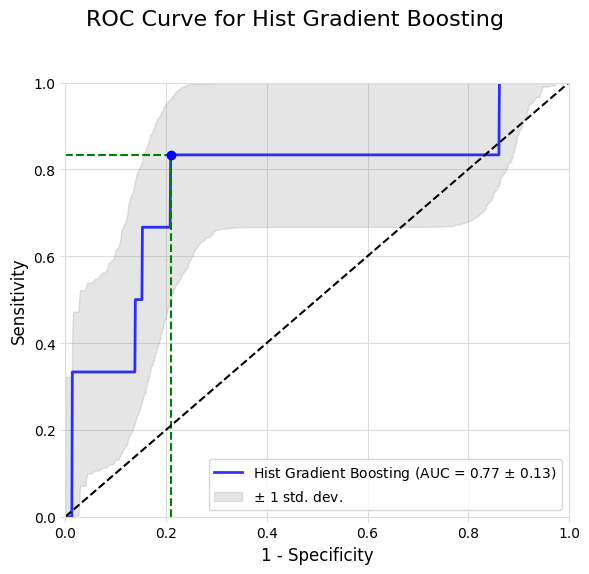

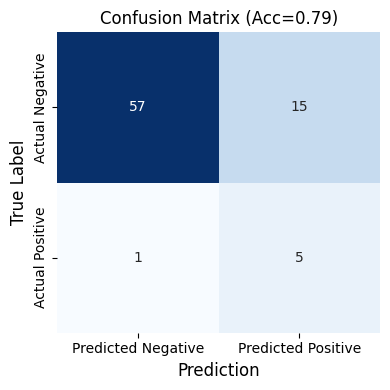

Results for Hist Gradient Boosting at Optimal Threshold:
AUC: 0.77
Accuracy: 0.79
Sensitivity (Recall): 0.83
Specificity: 0.79
Error with model Hist Gradient Boosting: index 209 is out of bounds for axis 0 with size 79
-----------------------------------------------

--- Analyzing Model: XGBoost ---


Traceback (most recent call last):
  File "C:\Users\nascime9\AppData\Local\Temp\ipykernel_16840\3191338975.py", line 207, in analyze_and_plot_models_fixed
    print(f"Optimal Threshold: {thrs[opt_idx]:.4f}")
                                ~~~~^^^^^^^^^
IndexError: index 209 is out of bounds for axis 0 with size 79
d:\Users\UFPB\gabriel ayres\MST\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:24:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Prediction probabilities - min: 0.0002, max: 0.9947
Test labels unique: [0 1]
Std Dev of AUCs: 0.0707


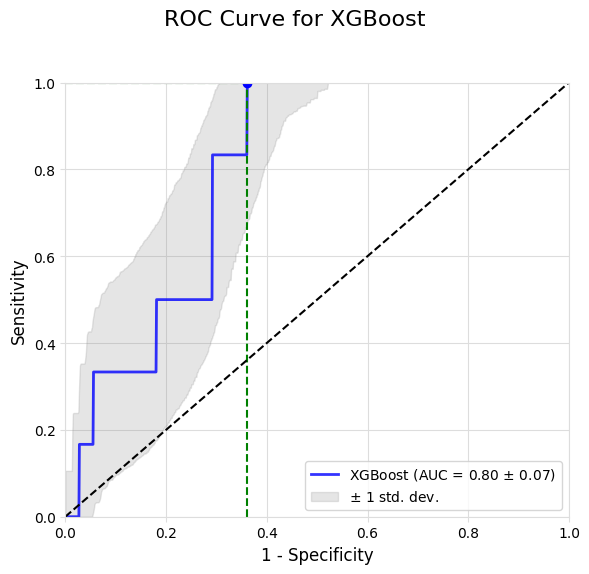

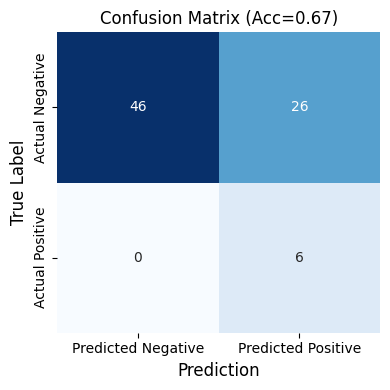

Results for XGBoost at Optimal Threshold:
AUC: 0.80
Accuracy: 0.67
Sensitivity (Recall): 1.00
Specificity: 0.64
Error with model XGBoost: index 361 is out of bounds for axis 0 with size 79
--------------------------------



Traceback (most recent call last):
  File "C:\Users\nascime9\AppData\Local\Temp\ipykernel_16840\3191338975.py", line 207, in analyze_and_plot_models_fixed
    print(f"Optimal Threshold: {thrs[opt_idx]:.4f}")
                                ~~~~^^^^^^^^^
IndexError: index 361 is out of bounds for axis 0 with size 79


In [ ]:

x_train, x_test, y_train, y_test = train_test_split(
    embeds, 
    labels, 
    test_size=0.2, 
    stratify=labels, 
    random_state=42
)

print("x_train shape before flattening:", x_train.shape)
print("x_test shape before flattening:", x_test.shape)

original_train_shape = x_train.shape
original_test_shape = x_test.shape

x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

print("x_train_flat shape:", x_train_flat.shape)
print("x_test_flat shape:", x_test_flat.shape)

smote = BorderlineSMOTE(random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train_flat, y_train)



def cm2acc(cm):
    # [[TN, FP], [FN, TP]] 
    tn, fp, fn, tp = cm.ravel()
    return (tn+tp)/(tn+tp+fn+fp)

def safe_div(x,y):
    if y == 0:
        return float('nan') 
    return x / y

def cm2x(cm):
    tn, fp, fn, tp = cm.ravel()
    pp = tp + fp  # predicted positive 
    pn = fn + tn  # predicted negative
    p = tp + fn   # actual positive
    n = fp + tn   # actual negative  

    ppv = safe_div(tp,pp)  # positive predictive value 
    npv = safe_div(tn,pn)  # negative predictive value 
    tpr = safe_div(tp,p)   # true positive rate (sensitivity, recall)
    tnr = safe_div(tn,n)   # true negative rate (specificity)
    # Note: other values are 1-x eg. fdr=1-ppv, for=1-npv, ....
    return ppv, npv, tpr, tnr

def auc_bootstrapping(y_true, y_score, bootstrapping=1000, drop_intermediate=True):
    tprs, aucs, thrs = [], [], []
    mean_fpr = np.linspace(0, 1, 1000) # Use 1000 points for a smooth average

    for _ in range(bootstrapping):
        # Bootstrap sample
        y_true_set, y_score_set = resample(y_true, y_score, replace=True, n_samples=len(y_true))

        # Ensure both classes are present
        if len(np.unique(y_true_set)) < 2:
            continue

        fpr, tpr, thresholds = roc_curve(y_true_set, y_score_set, drop_intermediate=drop_intermediate)
        optimal_idx = np.argmax(tpr - fpr) # Youden's J statistic

        tprs.append(np.interp(mean_fpr, fpr, tpr))
        aucs.append(auc(fpr, tpr))
        thrs.append(thresholds[optimal_idx])

    return tprs, aucs, thrs, mean_fpr



def plot_roc_curve(y_true, y_score, axis, bootstrapping=1000, drop_intermediate=False, fontdict={}, name='ROC', color='b', show_wp=True):
    # ----------- Bootstrapping ------------
    auc_check = roc_auc_score(y_true, y_score)
    if auc_check < 0.5:
        y_score = 1-y_score
    
    tprs_boot, aucs_boot, thrs_boot, mean_fpr = auc_bootstrapping(y_true, y_score, bootstrapping, drop_intermediate)

    mean_tpr = np.mean(tprs_boot, axis=0)
    mean_tpr[-1] = 1.0        
    std_tpr = np.std(tprs_boot, axis=0, ddof=1)
    tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
    tprs_lower = np.maximum(mean_tpr - std_tpr, 0)

    # ------ Averaged based on bootspraping ------
    mean_auc = np.mean(aucs_boot)
    std_auc = np.std(aucs_boot, ddof=1)
    print(f"Std Dev of AUCs: {std_auc:.4f}")
 

    # --------- Specific Case (the main curve) -------------
    fprs, tprs, thrs = roc_curve(y_true, y_score, drop_intermediate=drop_intermediate)
    auc_val = auc(fprs, tprs)

    # Interpolate the main ROC curve onto the same grid as the bootstrapped CIs
    interp_tpr = np.interp(mean_fpr, fprs, tprs)

    # Find optimal point on the interpolated curve
    opt_idx = np.argmax(interp_tpr - mean_fpr)
    opt_tpr = interp_tpr[opt_idx]
    opt_fpr = mean_fpr[opt_idx]
    
    # Find the threshold corresponding to the optimal point
    # We can find the original threshold that gives the closest (fpr, tpr) to our optimal one.
    opt_thr_idx = (np.abs(thrs - np.interp(opt_fpr, fprs, thrs))).argmin()
    opt_thr = thrs[opt_thr_idx]

    y_scores_bin = y_score >= opt_thr
    conf_matrix = confusion_matrix(y_true, y_scores_bin)
    
    # --- Plotting ---
    axis.plot(mean_fpr, interp_tpr, color=color, label=rf"{name} (AUC = {auc_val:.2f} $\pm$ {std_auc:.2f})",
                lw=2, alpha=.8)
    axis.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2, label=r'$\pm$ 1 std. dev.')
    if show_wp:
        axis.hlines(y=opt_tpr, xmin=0.0, xmax=opt_fpr, color='g', linestyle='--')
        axis.vlines(x=opt_fpr, ymin=0.0, ymax=opt_tpr, color='g', linestyle='--')
    axis.plot(opt_fpr, opt_tpr, color=color, marker='o') 
    axis.plot([0, 1], [0, 1], linestyle='--', color='k')
    axis.set_xlim([0.0, 1.0])
    axis.set_ylim([0.0, 1.0])
    
    axis.legend(loc='lower right')
    axis.set_xlabel('1 - Specificity', fontdict=fontdict)
    axis.set_ylabel('Sensitivity', fontdict=fontdict)
    
    axis.grid(color='#dddddd')
    axis.set_axisbelow(True)
    axis.tick_params(colors='#dddddd', which='both')
    for xtick in axis.get_xticklabels():
        xtick.set_color('k')
    for ytick in axis.get_yticklabels():
        ytick.set_color('k')
    for child in axis.get_children():
        if isinstance(child, matplotlib.spines.Spine):
            child.set_color('#dddddd')
 
    return interp_tpr, mean_fpr, auc_val, thrs, opt_idx, conf_matrix


def analyze_and_plot_models_fixed():
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'SVC': SVC(probability=True, random_state=42),
        'Hist Gradient Boosting': HistGradientBoostingClassifier(random_state=42),
        'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
    }

    fontdict = {'fontsize': 12}
    
    # Ensure we have the right data format
    print("Using data shapes:")
    print(f"x_train_resampled: {x_train_resampled.shape}")
    print(f"y_train_resampled: {y_train_resampled.shape}")
    print(f"x_test_flat: {x_test_flat.shape}")
    print(f"y_test: {y_test.shape}")
    print()

    for name, model in models.items():
        print(f"--- Analyzing Model: {name} ---")
        
        try:
            # Fit model on the resampled training data
            model.fit(x_train_resampled, y_train_resampled)
            
            # Get prediction probabilities on the test set
            y_prob = model.predict_proba(x_test_flat)[:, 1]
            
            # Debug the predictions
            print(f"Prediction probabilities - min: {y_prob.min():.4f}, max: {y_prob.max():.4f}")
            print(f"Test labels unique: {np.unique(y_test)}")
            
            fig_roc, ax_roc = plt.subplots(1, 1, figsize=(6, 6))
            
            # Use the fixed plot_roc_curve function
            tprs, fprs, auc_val, thrs, opt_idx, cm = plot_roc_curve(
                y_test, y_prob, ax_roc, fontdict=fontdict, name=name
            )
            
            fig_roc.suptitle(f'ROC Curve for {name}', fontsize=16)
            fig_roc.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.show()

            # Generate and show the Confusion Matrix
            acc = cm2acc(cm)
            _, _, sens, spec = cm2x(cm)
            
            df_cm = pd.DataFrame(data=cm, columns=['Predicted Negative', 'Predicted Positive'], 
                               index=['Actual Negative', 'Actual Positive'])
            fig_cm, ax_cm = plt.subplots(1, 1, figsize=(4, 4))
            sns.heatmap(df_cm, ax=ax_cm, cbar=False, fmt='d', annot=True, cmap='Blues')
            ax_cm.set_title(f'Confusion Matrix (Acc={acc:.2f})', fontdict=fontdict)
            ax_cm.set_xlabel('Prediction', fontdict=fontdict)
            ax_cm.set_ylabel('True Label', fontdict=fontdict)
            fig_cm.tight_layout()
            plt.show()

            # Print Summary Metrics
            print(f"Results for {name} at Optimal Threshold:")
            print(f"AUC: {auc_val:.2f}")
            print(f"Accuracy: {acc:.2f}")
            print(f"Sensitivity (Recall): {sens:.2f}")
            print(f"Specificity: {spec:.2f}")
            print(f"Optimal Threshold: {thrs[opt_idx]:.4f}")
            print(f"Confusion Matrix (TN, FP, FN, TP): {cm.ravel()}")
            print("-" * (25 + len(name)) + "\n")
            
        except Exception as e:
            
            print(f"Error with model {name}: {e}")
            import traceback
            traceback.print_exc()
            print("-" * (25 + len(name)) + "\n")

# Run the debugging first, then the analysis
print("Running analysis with fixed function...")
analyze_and_plot_models_fixed()
